In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [85]:
df = pd.read_csv('auto-mpg.csv')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [86]:
#change spaces for _
df = df.rename(columns={'model year': 'model_year', 'car name': 'car_name'})

In [87]:
df['origin'].value_counts()

#1 = american cars
#2 = europe
#3 japan

origin
1    249
3     79
2     70
Name: count, dtype: int64

In [88]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model_year        int64
origin            int64
car_name         object
dtype: object

In [89]:
#find the values that are not numeric in column horsepower and assigned it to the variable
non_numeric_hp = df[~df['horsepower'].str.replace('.', '', 1).str.isnumeric()]['horsepower'].unique()

print('Non-numeric horsepower values:', non_numeric_hp)

Non-numeric horsepower values: ['?']


In [90]:
#data cleaning

df['horsepower'].replace('?', np.nan, inplace=True) #replace ? with na

df['horsepower'] = pd.to_numeric(df['horsepower']) #convert horsepower to numeric

df.isnull().sum() #checking the missing values after replacing ? with na

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [91]:
mean_hp = df['horsepower'].mean()

df['horsepower'].fillna(mean_hp, inplace=True) #impute mean to na values


#origin could be useful for clustering, but for clustering only by car specs is best to drop it
df_clean = df.drop(columns=['origin', 'car_name']) #not useful for clustering 

df_clean.isna().sum()

C:\Users\Ramon\AppData\Local\Temp\ipykernel_9736\1161311534.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
dtype: int64

In [92]:
df_clean.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
dtype: object

In [93]:
corr = df.select_dtypes(include=['float64', 'int64']).corr() #excluding car_name (object type)
corr

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
mpg,1.000000,-0.775396,-0.804203,-0.771437,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.838939,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.893646,0.932824,-0.543684,-0.370164,-0.609409
horsepower,-0.771437,0.838939,0.893646,1.000000,0.860574,-0.684259,-0.411651,-0.453669
weight,-0.831741,0.896017,0.932824,0.860574,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.684259,-0.417457,1.000000,0.288137,0.205873
model_year,0.579267,-0.348746,-0.370164,-0.411651,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.453669,-0.581024,0.205873,0.180662,1.000000


In [94]:
# excluding origin and car_name
corr_clean = df_clean.corr(numeric_only=True)
corr_clean

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.775396,-0.804203,-0.771437,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.838939,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.893646,0.932824,-0.543684,-0.370164
horsepower,-0.771437,0.838939,0.893646,1.000000,0.860574,-0.684259,-0.411651
weight,-0.831741,0.896017,0.932824,0.860574,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.684259,-0.417457,1.000000,0.288137
model_year,0.579267,-0.348746,-0.370164,-0.411651,-0.306564,0.288137,1.000000


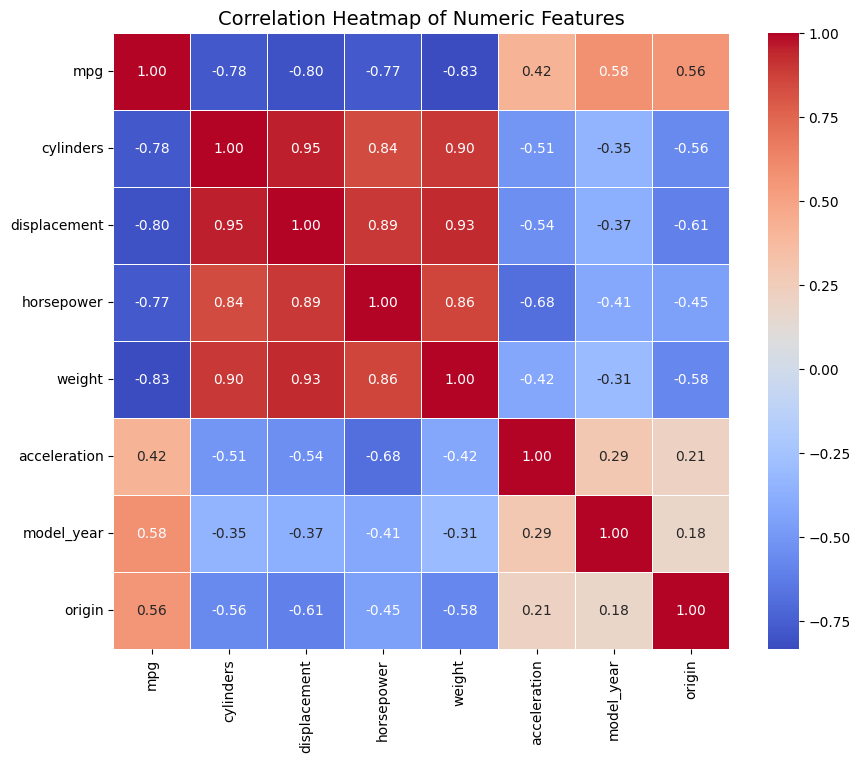

In [95]:
#correlation matrix
plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=.5)

plt.title('Correlation Heatmap of Numeric Features', fontsize=14)

plt.show()

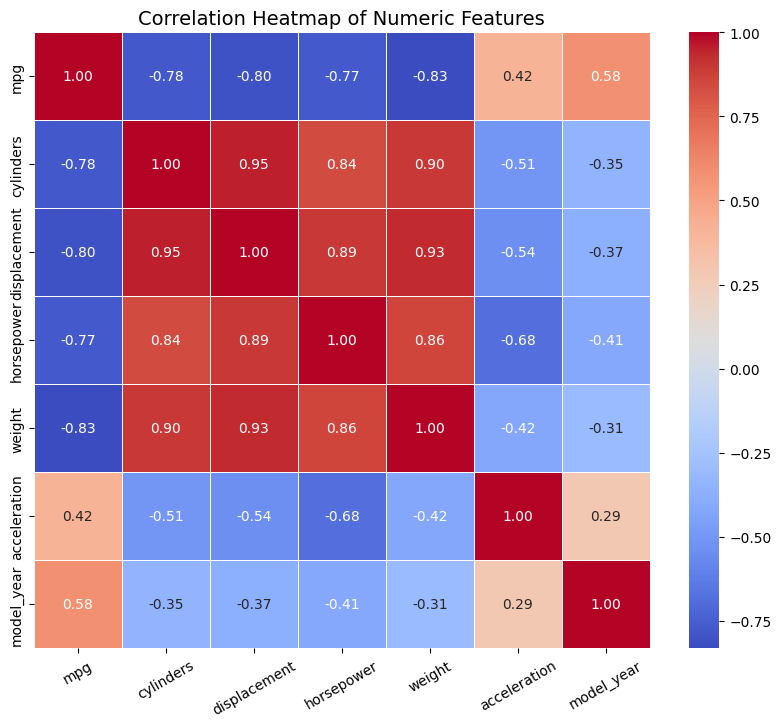

In [96]:
#correlation matrix
plt.figure(figsize=(10, 8))

sns.heatmap(corr_clean, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=.5)

plt.title('Correlation Heatmap of Numeric Features', fontsize=14)
plt.xticks(rotation=30)

plt.show()

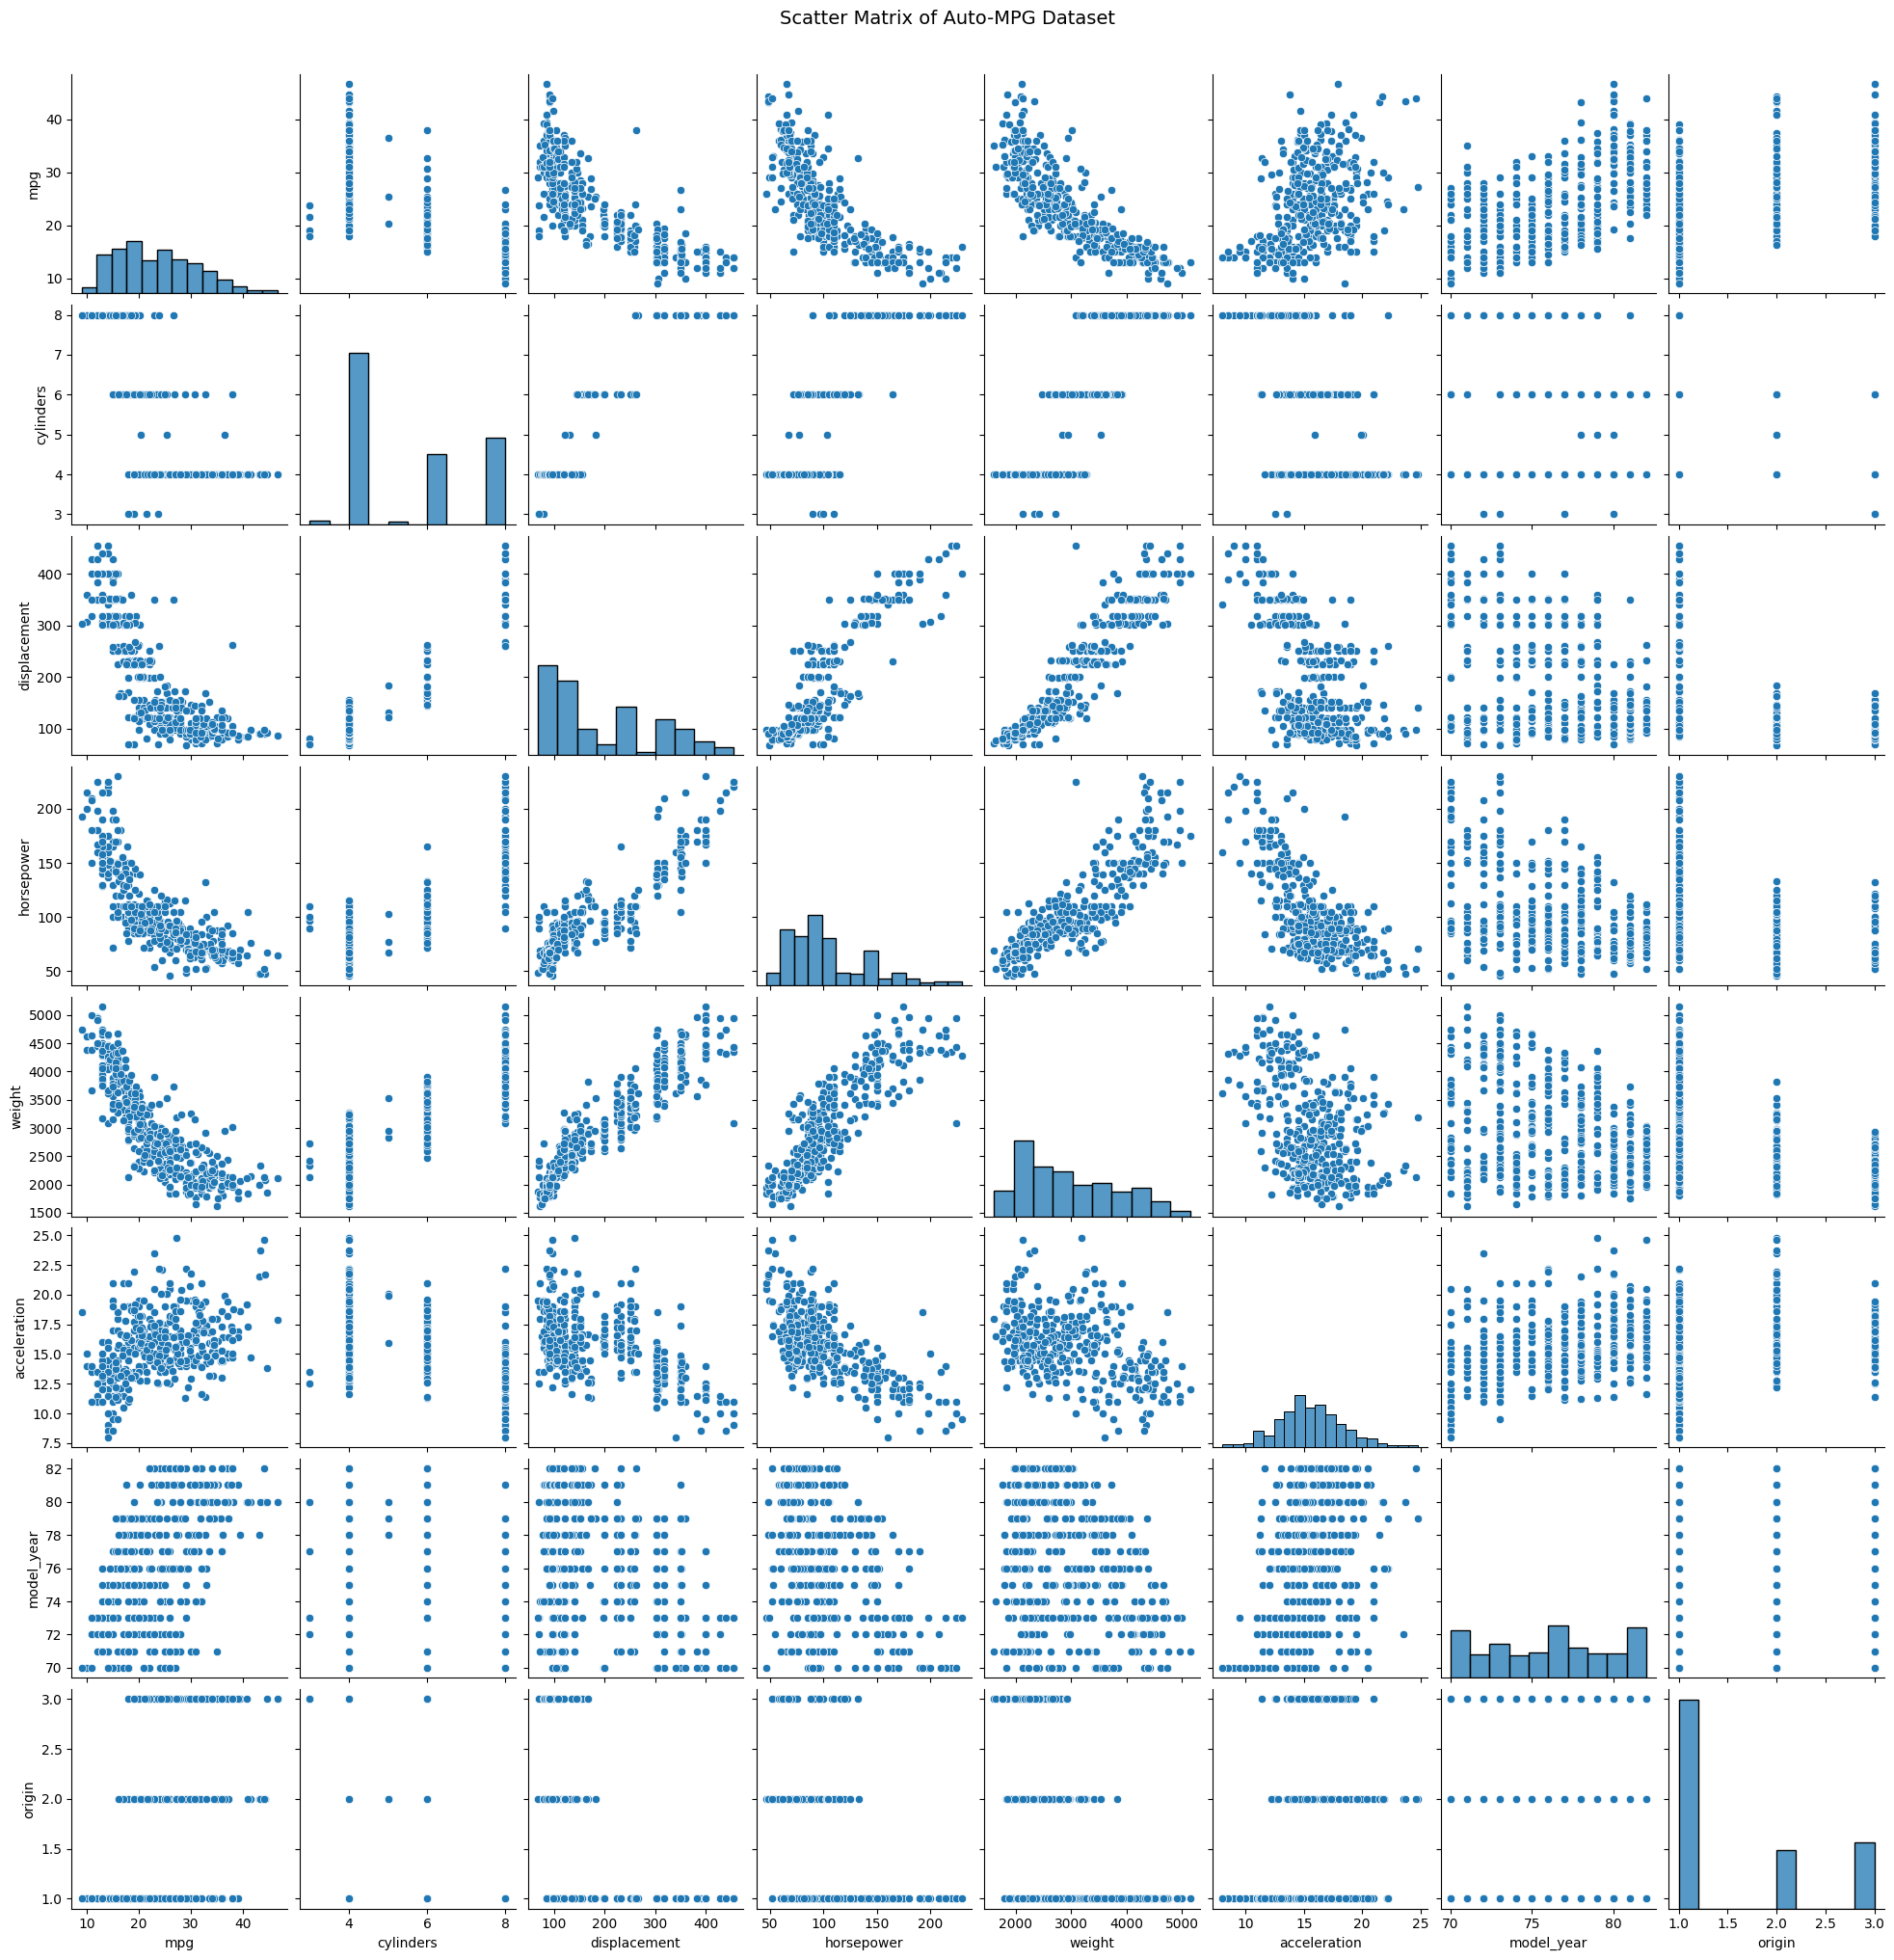

In [97]:
# scatter matrix
sns.pairplot(df, diag_kind='hist')
plt.suptitle('Scatter Matrix of Auto-MPG Dataset', y=1.02, fontsize=14)
plt.show()

In [98]:
#vif

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df_clean
X = add_constant(X)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,Feature,VIF
0,const,757.031966
1,mpg,5.227504
2,cylinders,10.604849
3,displacement,19.765922
4,horsepower,8.644376
5,weight,13.429119
6,acceleration,2.510462
7,model_year,1.910226


In [99]:
# above 10 means severe correlation between one or more variables, in this case weight, displacement and cylinders are strongly correlated
# (horsepower is also correlated but not as severe as the other variables mentioned above)
# displacement is the combined internal volume of all the engine's cylinders, generally more cylinders result in higher engine displacement
# more cylinders generally result in a heavier engine, thats why this 3 variables are highly correlated

# for regression this could be a problem, for unsupervised learning its expected

In [100]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df_clean
# creates a StandardScaler object that, when applied, will standardize each feature by removing its mean and scaling to unit variance
# scale = StandardScaler() -> just creates the tool (object) that knows how to standardize, but does nothing yet
scaler = StandardScaler()

# X_scaled = scaler.fit_transform(X) -> actually applies it to your dataset: first it learns the mean and std from X, then it uses it to standardize
X_scaled = scaler.fit_transform(X)

# creates a PCA object 
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

# creates a pandas dataframe summarizing pca results
explained_variance = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_)
})

print('Explained Variance per Principal Component:')
display(explained_variance.round(4))

#creates a df of PCA loadings
loadings = pd.DataFrame(pca.components_.T, #loading coefficients
                        columns=[f'PC{1+i}' for i in range(len(X.columns))],
                        index=X.columns)

print('Principal Component Loadings:')
display(loadings.round(4))

Explained Variance per Principal Component:


,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.7142,0.7142
1,PC2,0.1237,0.8379
2,PC3,0.1041,0.9420
3,PC4,0.0267,0.9687
4,PC5,0.0182,0.9869
5,PC6,0.0081,0.9950
6,PC7,0.0050,1.0000


Principal Component Loadings:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
mpg,-0.3979,0.2118,-0.2562,0.7477,0.3295,0.2356,-0.0898
cylinders,0.4166,0.1911,0.1409,0.4851,-0.4730,-0.3562,-0.4290
displacement,0.4299,0.1770,0.1037,0.2942,-0.0649,0.1465,0.8129
horsepower,0.4217,0.0918,-0.1680,-0.0393,0.7385,-0.4846,-0.0610
weight,0.4144,0.2215,0.2798,-0.1133,0.2264,0.7064,-0.3713
acceleration,-0.2848,-0.0245,0.8927,0.1262,0.2432,-0.2084,0.0534
model_year,-0.2294,0.9106,-0.0172,-0.2980,-0.0877,-0.1371,0.0508


In [101]:
# verify multicollinearity is gone
pc_corr = pd.DataFrame(X_pca).corr().round(3)
pc_corr

,0,1,2,3,4,5,6
0,1.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0
1,0.0,1.0,-0.0,-0.0,0.0,-0.0,0.0
2,-0.0,-0.0,1.0,-0.0,0.0,0.0,0.0
3,-0.0,-0.0,-0.0,1.0,-0.0,0.0,0.0
4,-0.0,0.0,0.0,-0.0,1.0,0.0,0.0
5,-0.0,-0.0,0.0,0.0,0.0,1.0,-0.0
6,0.0,0.0,0.0,0.0,0.0,-0.0,1.0


In [102]:
#Interactive graph #scree plot
import plotly.express as px

#prepare data
components = list(range(1, len(pca.explained_variance_ratio_) + 1))
variance_ratio = pca.explained_variance_ratio_
#create interactive line chart
fig = px.line(
    x = components,
    y = variance_ratio,
    markers = True,
    labels = {'x': 'Principal component', 'y': 'Explained Variance Ratio'},
    title = 'Scree plot'
)

fig.show()

When you run PCA (Principal Component Analysis), each PC captures a portion of the total variance of the dataset, ie, how much info that component contains.
The cumulative variance is how much of the original data variance is preserved

In [103]:
# choose the 3 first pca because the have a cumulative variance of at least 90%
# why 90%?
# It balances simplicity and information retention
x_pca_3 = X_pca[:, :3] 
x_pca_3

df_pca = pd.DataFrame(x_pca_3, columns=['PC1', 'PC2', 'PC3'])

df_pca

,PC1,PC2,PC3
0,2.660088,-0.919219,-0.559197
1,3.521679,-0.789385,-0.671600
2,2.996660,-0.861310,-0.982945
3,2.935927,-0.949077,-0.608106
4,2.929128,-0.931849,-1.079775
...,...,...,...
393,-1.422936,1.225087,-0.284198
394,-4.096867,1.278557,1.963547
395,-1.549408,1.253450,-1.904720
396,-2.024927,1.131461,0.611690


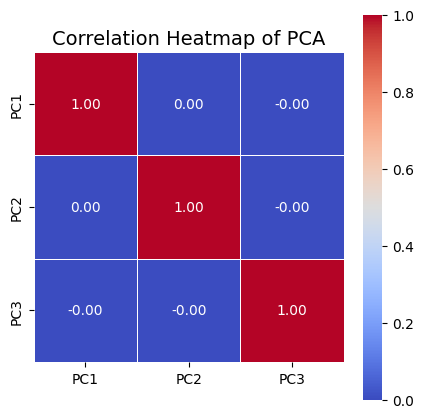

In [104]:
#heatmap of pca
plt.figure(figsize=(5, 5))

sns.heatmap(df_pca.corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=.5)

plt.title('Correlation Heatmap of PCA', fontsize=14)

plt.show()

In [105]:
#vif of pca #should be 1

X = df_pca
X = add_constant(X)
vif_pca = pd.DataFrame()
vif_pca['PCA'] = X.columns
vif_pca['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_pca

,PCA,VIF
0,const,1.0
1,PC1,1.0
2,PC2,1.0
3,PC3,1.0


Inertia: how close the data points in a cluster are to the clusters center.
Low Inertia: points are very close to their cluster centers
High Inertia: points are spread out

Because inertia always drops as you add clusters, we look for the point of diminishing returns (elbow)

In [106]:
from kneed import KneeLocator

In [107]:
# k means inertias
from sklearn.cluster import KMeans

inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df_pca)
    inertias.append(kmeans.inertia_)

inertias_df = pd.DataFrame(inertias, columns=['Inertia'])
inertias_df

,Inertia
0,2624.447341
1,1137.547440
2,797.310702
3,593.146972
4,524.824782
5,480.415055
6,435.949648
7,373.443693
8,345.839956
9,314.321656


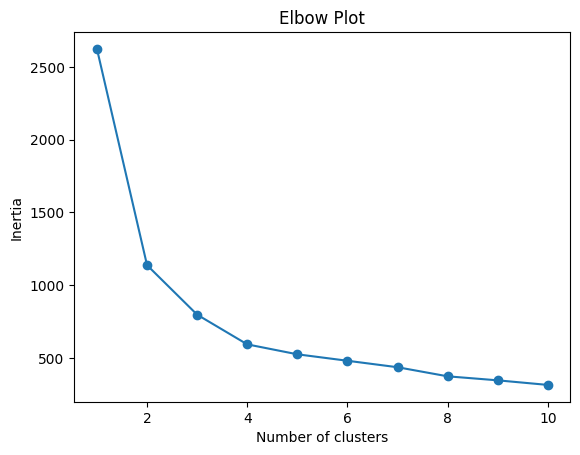

In [108]:
#elbow plot
plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow Plot')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [109]:
#kmeans clustering

kmeans = KMeans(n_clusters=3)
#kmeans.fit(df_pca)

df_pca['Cluster_KMeans'] = kmeans.fit_predict(df_pca)
df_pca

,PC1,PC2,PC3,Cluster_KMeans
0,2.660088,-0.919219,-0.559197,0
1,3.521679,-0.789385,-0.671600,0
2,2.996660,-0.861310,-0.982945,0
3,2.935927,-0.949077,-0.608106,0
4,2.929128,-0.931849,-1.079775,0
...,...,...,...,...
393,-1.422936,1.225087,-0.284198,2
394,-4.096867,1.278557,1.963547,2
395,-1.549408,1.253450,-1.904720,2
396,-2.024927,1.131461,0.611690,2


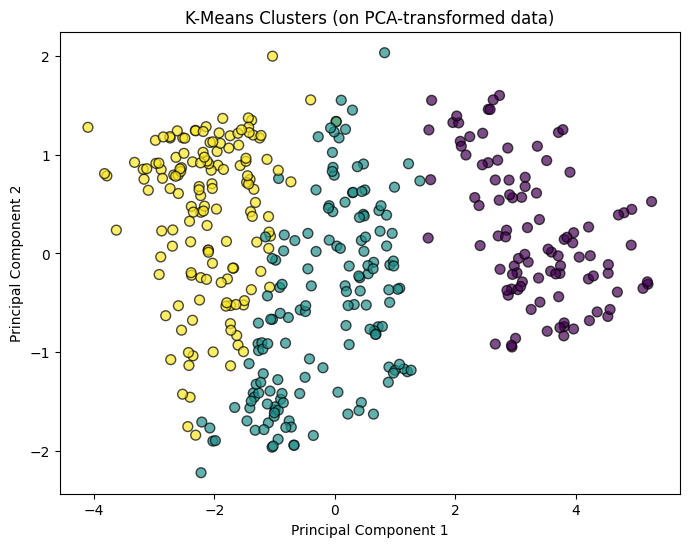

In [110]:
# Why only plot PC1 and PC2?
# PC1 and PC2 explain most of the variance (.83)

plt.figure(figsize=(8,6))
plt.scatter(df_pca['PC1'], df_pca['PC2'],
            c=df_pca['Cluster_KMeans'],  # color by cluster
            s=50, alpha=0.7, edgecolors='k')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters (on PCA-transformed data)')
plt.show()

Hierarchical Clustering

Instead of picking a number of clusters (k), hierachical clustering builds a tree (dendogram) that shows how data points merge together at different distance levels.

The linkage() function builds the hierarchy, it takes the data and computes the distance between points.

The method='' argument specifies how to to decide which clusters to merge.

Options for method='':

'ward': tries to minimize the variance within each cluster when merging, it tends to create compact, spherical clusters (similar to K-Means).

'single': merge based on the closest pair (can create long “chains”)

'complete':merge based on the farthest pair

'average':merge based on average distance

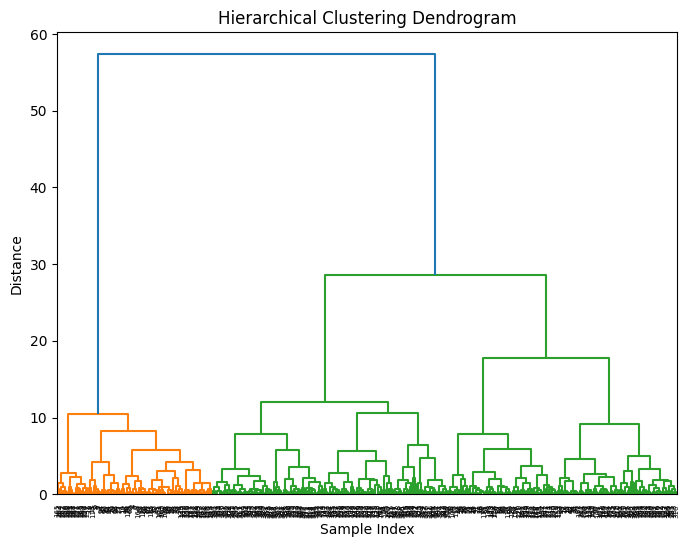

In [111]:
# hierarchical clustering

from scipy.cluster.hierarchy import linkage, dendrogram

#build the hierarchy
linkage_matrix = linkage(df_pca, method='ward')

#dendogram
plt.figure(figsize=(8, 6))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [112]:
from scipy.cluster.hierarchy import fcluster

#choose how many clusters
#fcluster() cuts the dendogram at the chosen level (t)
df_pca['Cluster_Hierarchical'] = fcluster(linkage_matrix, t=3, criterion='maxclust')
df_pca.head(20)

,PC1,PC2,PC3,Cluster_KMeans,Cluster_Hierarchical
0,2.660088,-0.919219,-0.559197,0,1
1,3.521679,-0.789385,-0.671600,0,1
2,2.996660,-0.861310,-0.982945,0,1
3,2.935927,-0.949077,-0.608106,0,1
4,2.929128,-0.931849,-1.079775,0,1
5,4.685161,-0.392640,-1.010114,0,1
6,5.192288,-0.312043,-1.369113,0,1
7,5.110360,-0.354419,-1.536988,0,1
8,5.183055,-0.288626,-1.042527,0,1
9,4.350298,-0.593414,-1.662316,0,1


In [113]:
df_pca['Cluster_KMeans'].value_counts()

Cluster_KMeans
1    154
2    144
0    100
Name: count, dtype: int64

In [114]:
df_pca['Cluster_Hierarchical'].value_counts()

Cluster_Hierarchical
2    151
3    147
1    100
Name: count, dtype: int64

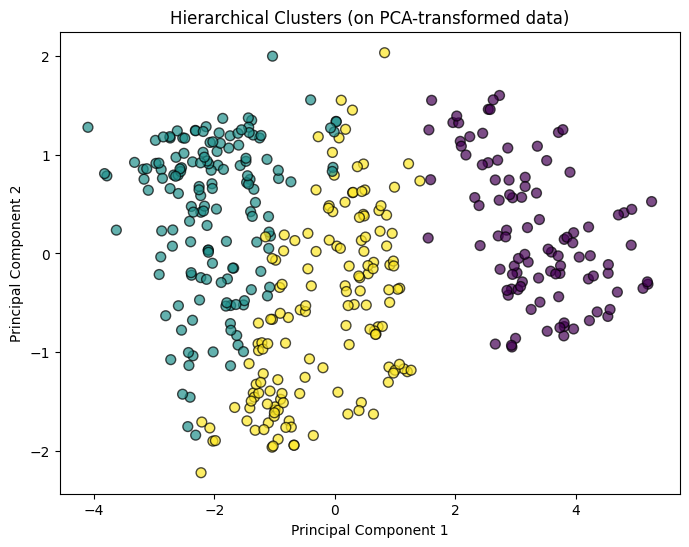

In [118]:
# scatter plot of hierarchical clustering
plt.figure(figsize=(8,6))
plt.scatter(df_pca['PC1'], df_pca['PC2'],
            c=df_pca['Cluster_Hierarchical'],
            s=50, alpha=0.7, edgecolors='k')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Hierarchical Clusters (on PCA-transformed data)')
plt.show()

Ajusted Rand Index: is a metric for measuring the similarity between two data partitions or clusterings.

It goes from +1 to -1.

1 its identical clusters, 0 its random and -1 its completely different

In [116]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(df_pca['Cluster_KMeans'], df_pca['Cluster_Hierarchical'])
print(f"Adjusted Rand Index (ARI): {ari:.3f}")

#.907 means both methods gave almost identical clusters


Adjusted Rand Index (ARI): 0.943


In [117]:
#comparison of clusters

df_clusters = pd.concat(
    [df_clean.reset_index(drop=True),
     df_pca[['Cluster_KMeans', 'Cluster_Hierarchical']]],
    axis=1
)

cluster_summary = df_clusters.groupby('Cluster_KMeans').mean(numeric_only=True).reset_index()
cluster_summary


,Cluster_KMeans,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,Cluster_Hierarchical
0,0,14.715000,7.980000,346.370000,160.550000,4126.910000,12.721000,73.750000,1.000000
1,1,21.470779,5.123377,173.353896,95.259343,2871.448052,16.369481,74.636364,2.954545
2,2,31.811111,4.055556,108.680556,75.374150,2273.159722,16.688194,79.048611,2.000000


# Summary and conclusion

At first sight, it seems that clusters 1 and 3 group the most efficient vehicles, with an average of 29.44 MPG and fewer cylinders (4).
Clusters 2 and 1 contain the most powerful vehicles, characterized by 8 cylinders, the heaviest average weight, and the highest horsepower, also the slowest and oldest cars.
Cluster 0 and 2 represent something in between, but based on their values, I think they are closer to clusters 2 and 1 than to 1 and 3.<br>

In summary, both methods grouped cars in very similar ways:<br>
Cluster 2 (K-Means) and Cluster 1 (Hierarchical): heavy, low-MPG, old, powerful cars<br>
Cluster 0 (K-Means) and Cluster 2 (Hierarchical): mid-sized, average-performance cars<br>
Cluster 1 (K-Means) and Cluster 3 (Hierarchical): small, high-MPG, efficient, newer cars<br>

How did the combination of PCA and clustering work?<br>
PCA reduced redundancy among highly correlated variables (weight, displacement, and cylinders), while clustering identified similar groups of vehicles based on those transformed, uncorrelated features.
